In [1]:
from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import lax
from jax import numpy as jnp
from jax.scipy.fft import dctn, idctn
import numpy as np
from functools import partial

from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast
from uot.utils.central_gradient_nd import _central_gradient_nd

from collections.abc import Sequence
from typing import Optional
from functools import reduce

from uot.data.measure import GridMeasure

from functools import partial
from typing import Callable, Optional, Tuple, Dict, Any

from matplotlib import pyplot as plt

In [2]:
plt.rcParams['figure.dpi'] = 120  # Set the display DPI for inline plots
plt.rcParams['savefig.dpi'] = 120 # Set the default DPI for saved figures

## Few utility functions

In [3]:
def _wait_jax_finish(result: dict[str, Any]) -> dict[str, Any]:
    """Block until all JAX arrays in `result` are ready."""
    # tree_map was removed and need to use tree.map?
    # ну ебать его в рот, я хуй знает как оно там в джаксе
    return jax.tree.map(
        lambda x: x.block_until_ready() if isinstance(x, jax.Array) else x,
        result
    )


def _row_major_strides_py(shape):
    """Row-major (C-order) strides for flattening (static Python ints)."""
    d = len(shape)
    strides_py = []
    p = 1
    for k in range(d - 1, -1, -1):
        strides_py.insert(0, p)
        p *= shape[k]
    return strides_py


def _cell_centers_physical(shape, dtype):
    """
    Cell centers for n_i cells per axis:
        x_i = (i + 0.5) / n_i
    Returns x with shape (d, *shape).
    """
    d = len(shape)
    idx = jnp.indices(shape, dtype=dtype)  # (d, *shape)
    n_vec = jnp.array(shape, dtype=dtype).reshape((d,) + (1,) * d)
    return (idx + 0.5) / n_vec


def physical_to_index_cell_centered(y: jnp.ndarray, shape, *, clip_eps: float = 1e-6) -> jnp.ndarray:
    """
    Convert physical coords y in [0,1]^d to continuous index coords s suitable for CIC
    on a cell-centered grid (cell masses).

    y:     (d, *shape) physical coords
    shape: tuple of grid sizes (n1, n2, ..., nd)

    Returns:
      s: (d, *shape) continuous index coords where integer j corresponds to cell center.
         (So y=(j+0.5)/n  <=>  s=j.)
    """
    d = len(shape)
    n_vec = jnp.array(shape, dtype=y.dtype).reshape((d,) + (1,) * d)
    y = jnp.clip(y, 0.0, 1.0 - clip_eps)
    s = y * n_vec - 0.5
    return s


## Monge Map Construction

In [4]:
def monge_map_cic_from_psi_nd(psi: jnp.ndarray) -> jnp.ndarray:
    """
    Build a Monge map in index coordinates.
    """
    shape = psi.shape
    d = psi.ndim
    n_vec = jnp.array(shape, dtype=jnp.float32).reshape((d,) + (1,) * d)

    grad = _central_gradient_nd(psi)
    idx = jnp.indices(shape, dtype=jnp.float32)
    # s_raw = idx + 0.5 + grad * n_vec
    # s_raw = idx + grad * n_vec
    s_raw = idx - grad * n_vec
    clipped = []
    for ax in range(d):
        clipped.append(jnp.clip(s_raw[ax], 0.0, shape[ax] - 1.0))
    return jnp.stack(clipped, axis=0)

## Pushforward Procedures

In [5]:
def cic_pushforward_nd(
        density: jnp.ndarray,
        monge_map: jnp.ndarray,
        ) -> jnp.ndarray:
    """
    Pushforward a density field along the flow defined by psi.
    - density: (n_1, n_2, ..., n_d) array of nonnegative values
    - psi:     (n_1, n_2, ..., n_d) array of potential values
    Returns:
    - new_density: (n_1, n_2, ..., n_d) array of nonnegative values
    - grad: (d, n_1, n_2, ..., n_d) array of gradients of psi
    Assumes uniform grid on [0,1]^d with grid spacing h_i = 1/n_i.
    Uses multilinear interpolation (bilinear in 2D, trilinear in 3D, etc).
    Boundary: clamp to [0, n_k - 1] in each dimension.
    0.5*||x||^2 is implicit in the definition of psi.
    1. Compute grad psi
    2. Compute fractional index s = i + grad psi * n
       (vertex-centered interpretation)
    3. Clip s to [0, n_k - 1] in each dimension
    4. Compute base = floor(s) and frac = s - base
    5. Scatter density to 2^d corners with multilinear weights
    """
    shape = density.shape
    d = density.ndim
    mdtype = monge_map.dtype

    base = jnp.floor(monge_map).astype(jnp.int32)
    frac = monge_map - base.astype(mdtype)

    # --- flatten using static sizes (no int() on tracers) ---
    density_flat = density.reshape(-1)                     # OK: -1 uses static size
    base_flat    = base.reshape(d, -1)
    frac_flat    = frac.reshape(d, -1)

    strides = jnp.array(
        _row_major_strides_py(shape),
        dtype=jnp.int32,
        ).reshape(d, 1)

    out = jnp.zeros_like(density_flat)

    def corner_body(m, out_acc):
        bits = jnp.array([(m >> k) & 1 for k in range(d)], dtype=jnp.int32).reshape(d, 1)
        corner_idx = base_flat + bits                      # (d,N)
        w = jnp.where(bits == 1, frac_flat, 1.0 - frac_flat)
        w = jnp.prod(w, axis=0)                            # (N,)
        flat_idx = jnp.sum(corner_idx * strides, axis=0)   # (N,)
        return out_acc.at[flat_idx].add(density_flat * w)

    out = lax.fori_loop(0, 1 << d, corner_body, out)
    return out.reshape(shape)

In [6]:
@partial(jax.jit, static_argnames=('maxiterations', 'progressbar',
                                  'stepsize_lower_bound', 'error_metric',
                                  'monge_map_fn',
                                  'pushforward_fn'))
def backnforth_sqeuclidean_nd(
        mu: jnp.ndarray,                 # shape (n0,...,nd-1)
        nu: jnp.ndarray,                 # shape (n0,...,nd-1)
        coordinates: list[jnp.ndarray],  # len d, each length n_k
        stepsize: float,
        maxiterations: int,
        tolerance: float = 1e-4,
        progressbar: bool = False,
        pushforward_fn=cic_pushforward_nd,
        monge_map_fn=monge_map_cic_from_psi_nd,
        stepsize_lower_bound: float = 0.01,
        error_metric: str = 'h1_psi_relative',
    ):
    """
    Dimension-agnostic BFM with quadratic cost on a uniform tensor grid in [0,1]^d.

    error_metric: 'tv_psi' | 'tv_phi' | 'l_inf_psi' | 'h1_psi' | 'h1_psi_relative'
                  | 'transportation_cost' | 'transportation_cost_relative'
    """

    # checks (lightweight; keep in Python tracer-friendly)
    shape = mu.shape
    assert nu.shape == shape
    d = len(coordinates)
    assert d == mu.ndim == nu.ndim
    for k in range(d):
        assert coordinates[k].shape[0] == shape[k]
    init_stepsize = stepsize
    armijo_upper = 0.75
    armijo_lower = 0.25
    armijo_scale_down = 0.95


    # c-transform for quadratic cost
    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # precompute kernel and r^2 grid
    hs = [c[1] - c[0] for c in coordinates]         # cell width
    Ls = [hs[k] * shape[k] for k in range(d)]       # true length = N*h
    # Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu.dtype)
    xmins = jnp.array([c[0] - 0.5*hs[k] for k,c in enumerate(coordinates)])
    xmaxs = jnp.array([c[-1] + 0.5*hs[k] for k,c in enumerate(coordinates)])
    r2 = _r2_from_coords(coordinates)
    cell_vol = jnp.prod(jnp.array([c[1] - c[0] for c in coordinates], dtype=mu.dtype))
    mu_nu_grid_sum = 0.5 * (r2 * (mu + nu)).sum()


    def dct_neumann_poisson(f):
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,)*f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    def update_potential(phi, rho, target, sigma):
        residual = target - rho
        pde_solution = dct_neumann_poisson(residual)
        new_phi = phi + sigma * pde_solution
        grad_sq = cell_vol * jnp.vdot(residual, pde_solution).real
        return new_phi, pde_solution, grad_sq

    # Dual objective (quadratic cost):  ½∫|x|² (μ+ν) - ∫ν φ - ∫μ ψ
    def dual_value(phi, psi):
        return cell_vol * (mu_nu_grid_sum - (phi * mu).sum() - (psi * nu).sum())

    # Armijo–Goldstein heuristic
    def stepsize_update(sigma, value, old_value, grad_sq,
                        upper=armijo_upper,
                        lower=armijo_lower,
                        scale_down=armijo_scale_down):
        scale_up = 1.0 / scale_down
        gain = value - old_value
        old_sigma = sigma
        sigma = jnp.where(
            gain > sigma * upper * grad_sq,
            sigma * scale_up, sigma
        )
        sigma = jnp.where(
            gain < sigma * lower * grad_sq,
            sigma * scale_down, sigma
        )
        sigma = jnp.maximum(sigma, stepsize_lower_bound)
        return sigma

    def compute_error(iter_idx, dual_curr, dual_prev, grad_curr, grad_prev,
                      rho_mu=None, rho_nu=None):
        if error_metric == 'tv_psi':
            err = 0.5 * jnp.sum(jnp.abs(rho_mu - nu))
        elif error_metric == 'tv_phi':
            err = 0.5 * jnp.sum(jnp.abs(rho_nu - mu))
        elif error_metric == 'l_inf_psi':
            err = jnp.max(jnp.abs(rho_mu - nu))
        elif error_metric == 'h1_psi':
            err = grad_curr
        elif error_metric == 'h1_psi_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(grad_prev - grad_curr) / jnp.maximum(grad_curr, 1e-10),
            )
        elif error_metric == 'transportation_cost':
            err = jnp.abs(dual_prev - dual_curr)
        elif error_metric == 'transportation_cost_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(dual_prev - dual_curr) / jnp.maximum(jnp.abs(dual_curr), 1e-10),
            )
        else:
            raise ValueError(f"Unknown error_metric: {error_metric}")
        return err
    def body(state):
        (i, phi, psi, sigma, dual_prev, grad_prev,
         errors, dual_values, sigma_history) = state

        monge_map_psi = monge_map_fn(psi)
        rho_mu = pushforward_fn(mu, monge_map_psi)
        phi, _, _ = update_potential(phi, rho_mu, nu, sigma)
        psi = c_transform(phi)
        # phi = c_transform(psi)  # ensure consistency

        monge_map_phi = monge_map_fn(phi)
        rho_nu = pushforward_fn(nu, monge_map_phi)
        psi, _, grad_sq_psi = update_potential(psi, rho_nu, mu, sigma)
        phi = c_transform(psi)
        # psi = c_transform(phi)  # ensure consistency

        dual_curr = dual_value(phi, psi)
        sigma_new = stepsize_update(sigma, dual_curr, dual_prev, grad_sq_psi)
        err = compute_error(i, dual_curr, dual_prev, grad_sq_psi, grad_prev,
                            rho_mu=rho_mu, rho_nu=rho_nu)

        errors = errors.at[i].set(err)
        dual_values = dual_values.at[i].set(dual_curr)
        sigma_history = sigma_history.at[i].set(sigma_new)

        if progressbar:
            jax.debug.print("[{}] error = {}; dual = {};",
                            i, errors[i], dual_values[i])

        return (i + 1, phi, psi, sigma_new, dual_curr, grad_sq_psi,
                errors, dual_values, sigma_history)

    def cond(state):
        i = state[0]
        errors = state[6]
        curr_error = errors[jnp.maximum(i - 1, 0)]
        return (i < maxiterations) & (curr_error > tolerance)

    phi0 = jnp.zeros_like(mu)
    psi0 = jnp.zeros_like(nu)
    dual0 = dual_value(phi0, psi0)
    grad0 = 0.0

    errors0 = jnp.full((maxiterations,), jnp.inf, dtype=mu.dtype)
    dual_values0 = jnp.full((maxiterations,), dual0, dtype=mu.dtype)
    sigma_history0 = jnp.full((maxiterations,), stepsize, dtype=mu.dtype)

    init_state = (jnp.array(0, dtype=jnp.int32), phi0, psi0,
                  jnp.asarray(init_stepsize, dtype=mu.dtype), dual0, grad0,
                  errors0, dual_values0, sigma_history0)

    state = lax.while_loop(cond, body, init_state)
    iterations, phi, psi, _, _, _, errors, dual_values, sigma_history = state

    rho_mu = pushforward_fn(mu, monge_map_fn(psi))
    rho_nu = pushforward_fn(nu, monge_map_fn(phi))
    results = {
        'iterations': iterations,
        'phi': phi,
        'psi': psi,
        'rho_nu': rho_nu,
        'rho_mu': rho_mu,
        'errors': errors,
        'dual_history': dual_values,
        'sigma_history': sigma_history,
    }
    return results


def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


---

# BARYCENTERS WITH BACK-AND-FORTH METHOD

In [7]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice

from jax import config
config.update("jax_enable_x64", True)

sys.path.insert(0, os.path.abspath(os.path.join('..')))

import jax.numpy as jnp
from functools import partial
from collections.abc import Sequence
from typing import Callable, Optional

from uot.problems.generators import GaussianMixtureBarycenterGenerator
from uot.utils.costs import cost_euclid_squared

# from uot.solvers.back_and_forth.forward_pushforward import cic_pushforward_nd
from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast

from uot.solvers.back_and_forth.barycenter import backnforth_barycenter_sqeuclidean_nd_optimized
import time


### Barycenter Problem Construction

In [8]:
def plot_measure(ax, measure, title, cmap='viridis'):
    if hasattr(measure, 'weights_nd') and hasattr(measure, 'axes'):
        axes = measure.axes
        weights = np.asarray(measure.weights_nd)
        if len(axes) == 1:
            x = np.asarray(axes[0])
            ax.plot(x, weights.reshape(-1))
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            return
        extent = (
            float(axes[0][0]), float(axes[0][-1]),
            float(axes[1][0]), float(axes[1][-1]),
        )
        ax.imshow(weights.T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        ax.set_axis_off()
        return

    points, weights = measure.to_discrete()
    points = np.asarray(points)
    weights = np.asarray(weights)
    if points.ndim == 1:
        points = points.reshape(-1, 1)
    if points.shape[1] == 1:
        ax.plot(points[:, 0], weights)
    else:
        ax.scatter(points[:, 0], points[:, 1], c=weights, s=8, cmap=cmap)
    ax.set_title(title)
    ax.set_axis_off()


In [9]:
# Instantiate the generator (2D case).

gen = GaussianMixtureBarycenterGenerator(
    name="gmm-bary",
    dim=2,
    num_components=1,
    n_points=32,
    num_datasets=3,
    borders=(0.0, 1.0),
    cost_fn=cost_euclid_squared,
    num_marginals=3,
    use_jax=True,
    seed=42,
    measure_mode="grid",
    cell_discretization="cell-centered",
)

problems = list(islice(gen.generate(), 3))


### Helper functions to solve Poisson Equation

In [10]:
def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


### Entropic Barycenter Back-and-Forth method

In [11]:
from functools import partial
from typing import Callable, Optional, Sequence, Tuple, Dict, Any

import jax
import jax.numpy as jnp
from jax import lax


def entropic_barycenter_sobolev_gradient_ascent_dual_scan(
    mu_list: Sequence[jnp.ndarray],
    lambda_list: Sequence[float] | jnp.ndarray,
    coordinates: Sequence[jnp.ndarray],
    gamma: float,
    *,
    num_outer_iters: int = 30,
    outer_tol: Optional[float] = None,     # used only for post-processing (no early break in scan)
    eta: float = 4.0,
    pushforward_fn: Callable = cic_pushforward_nd,
    armijo_upper: float = 0.75,
    armijo_lower: float = 0.25,
    armijo_scale_down: float = 0.95,
    stepsize_lower_bound: float = 0.01,
    progressbar: bool = False,
):
    """
    JAX-friendly refactor using lax.scan.

    Notes:
    - This matches the behavior of the cleaned Python-loop version:
      ψ is updated only via ψ := c(φ) (no explicit ψ gradient step).
    - For maximum speed, this returns *minimal* diagnostics (mass + mismatches).
    - Early stopping is not done inside scan; you can post-process outer_tol.
    """

    # ---------------- checks / normalize ----------------
    if len(mu_list) == 0:
        raise ValueError("mu_list must contain at least one marginal.")
    if gamma <= 0:
        raise ValueError("gamma must be strictly positive.")

    mus = [jnp.asarray(mu) for mu in mu_list]
    shape = mus[0].shape
    for i, mu in enumerate(mus):
        if mu.shape != shape:
            raise ValueError(
                f"All marginals must share one grid shape. mu_list[0]={shape}, mu_list[{i}]={mu.shape}."
            )

    mu_stack = jnp.stack(mus, axis=0)  # (n, *grid)
    n = mu_stack.shape[0]

    weights = jnp.asarray(lambda_list, dtype=mu_stack.dtype)
    if weights.ndim != 1 or weights.shape[0] != n:
        raise ValueError(f"lambda_list must have shape ({n},), got {weights.shape}.")
    weights = weights / jnp.maximum(weights.sum(), jnp.finfo(weights.dtype).eps)

    gamma = jnp.asarray(gamma, dtype=mu_stack.dtype)
    eta = jnp.asarray(eta, dtype=mu_stack.dtype)
    stepsize_lower_bound = jnp.asarray(stepsize_lower_bound, dtype=mu_stack.dtype)

    # ---------------- operators ----------------
    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # kernel for Neumann Poisson solve (H1 gradient)
    # NOTE: if neumann_kernel_nd expects python floats, you may want to precompute kernel outside jit.
    Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu_stack.dtype)

    def dct_neumann_poisson(f):
        # mean-zero Neumann solve: u = (-Δ)^(-1) f
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,) * f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    # vmap versions (apply per marginal i)
    cT_vmap = jax.vmap(c_transform, in_axes=0, out_axes=0)

    def gibbs_nu(phi_stack):
        # phi_stack: (n, *grid)
        A = jnp.tensordot(weights, phi_stack, axes=(0, 0))  # (*grid)
        logits = -(A / gamma)
        logits = logits - jnp.max(logits)
        nu = jnp.exp(logits)
        nu = nu / jnp.maximum(nu.sum(), jnp.finfo(nu.dtype).eps)
        return nu

    def push_mu_through_potential(mu_i, pot_i):
        # IMPORTANT: this must be JAX-traceable.
        # It assumes monge_map_cic_from_psi_nd(pot_i) returns an array-like map object (not a Python callable).
        return pushforward_fn(mu_i, monge_map_cic_from_psi_nd(pot_i))

    push_mu_vmap = jax.vmap(push_mu_through_potential, in_axes=(0, 0), out_axes=0)

    def push_nu_through_potential(nu, pot_i):
        return pushforward_fn(nu, monge_map_cic_from_psi_nd(pot_i))

    # sum over grid dims (all dims except leading n)
    grid_axes = tuple(range(1, mu_stack.ndim))

    # Dual value for D(psi) (defined inline per request)
    def dual_value_psi(psi_stack):
        phi_stack = cT_vmap(psi_stack)
        term1 = jnp.sum(psi_stack * mu_stack, axis=grid_axes)
        term1 = jnp.tensordot(weights, term1, axes=(0, 0))
        A = jnp.tensordot(weights, phi_stack, axes=(0, 0))
        logits = -(A / gamma)
        m = jnp.max(logits)
        logZ = jnp.log(jnp.sum(jnp.exp(logits - m))) + m
        return term1 - gamma * logZ

    # Armijo–Goldstein heuristic
    def stepsize_update(sigma, value, old_value, grad_sq,
                        upper=armijo_upper,
                        lower=armijo_lower,
                        scale_down=armijo_scale_down):
        scale_up = 1.0 / scale_down
        gain = value - old_value
        old_sigma = sigma
        sigma = jnp.where(
            gain > sigma * upper * grad_sq,
            sigma * scale_up, sigma
        )
        sigma = jnp.where(
            gain < sigma * lower * grad_sq,
            sigma * scale_down, sigma
        )
        if progressbar:
            jax.debug.print("[stepsize_update] gain = {}; up = {}; low = {}; sigma {} -> {}",
                            gain, grad_sq * sigma * upper,
                            grad_sq * sigma * lower, old_sigma, sigma)
        sigma = jnp.maximum(sigma, stepsize_lower_bound)
        return sigma

    # ---------------- scan step ----------------
    def step(carry, _):
        # carry: (psi_stack, sigma, dual_prev)
        psi_stack, sigma, dual_prev = carry

        # (1) ψ -> φ
        phi_stack = cT_vmap(psi_stack)

        # (2) Gibbs ν(φ)
        nu = gibbs_nu(phi_stack)

        # (3) compute ν̃_i from μ_i using ψ_i := c(φ_i)
        psi_from_phi = cT_vmap(phi_stack)  # (n, *grid)
        nu_tilde = push_mu_vmap(mu_stack, psi_from_phi)  # (n, *grid)

        # (4) φ ascent (H1 gradient)
        w = weights.reshape((n,) + (1,) * (mu_stack.ndim - 1))
        residual = w * (nu[None, ...] - nu_tilde)
        delta = jax.vmap(dct_neumann_poisson, in_axes=0, out_axes=0)(residual)
        grad_sq = jnp.sum(residual * delta)
        phi_next = phi_stack + sigma * delta

        # (5) ψ := c(φ_next)
        psi_next = cT_vmap(phi_next)

        dual_curr = dual_value_psi(psi_next)
        sigma_next = stepsize_update(sigma, dual_curr, dual_prev, grad_sq)

        # mismatch phase (same as your cleaned loop):
        nu2 = gibbs_nu(phi_next)

        def mu_tilde_i(pot_i):
            return push_nu_through_potential(nu2, pot_i)

        mu_tilde = jax.vmap(mu_tilde_i, in_axes=0, out_axes=0)(phi_next)  # (n, *grid)

        mism = jnp.sum(jnp.abs(mu_stack - mu_tilde), axis=grid_axes)  # (n,)
        max_mism = jnp.max(mism)
        mass_nu = jnp.sum(nu2)

        # carry psi for next iter; outputs are diagnostics
        return (psi_next, sigma_next, dual_curr), (mass_nu, mism, max_mism, sigma_next, dual_curr, grad_sq)

    # initial ψ = 0
    psi0 = jnp.zeros_like(mu_stack)
    dual0 = dual_value_psi(psi0)

    # run scan
    (psi_final, sigma_final, dual_final), (mass_hist, mism_hist, max_mism_hist,
                                          sigma_hist, dual_hist, grad_sq_hist) = lax.scan(
        step, (psi0, eta, dual0), xs=None, length=num_outer_iters
    )

    # final φ, ν
    phi_final = cT_vmap(psi_final)
    nu_final = gibbs_nu(phi_final)

    diagnostics = {
        "iterations": num_outer_iters,
        "mass_nu": mass_hist,                 # (T,)
        "source_mismatch": mism_hist,         # (T, n)
        "max_source_mismatch": max_mism_hist, # (T,)
        "eta_history": sigma_hist,            # (T,)
        "dual_history": dual_hist,            # (T,)
        "grad_sq_history": grad_sq_hist,      # (T,)
    }

    # optional: postprocess early-stop index on host (or inside JAX if you want)
    if outer_tol is not None:
        tol = jnp.asarray(outer_tol, dtype=max_mism_hist.dtype)
        done = max_mism_hist <= tol
        any_done = jnp.any(done)
        first_done = jnp.argmax(done)  # 0 if none OR first is done; disambiguate with any_done
        iters_to_tol = jnp.where(any_done, first_done + 1, num_outer_iters)
        diagnostics["iters_to_tol"] = iters_to_tol
        diagnostics["met_tol_mask"] = done

    return nu_final, psi_final, phi_final, diagnostics


In [12]:
def _stack_grid_measures(measures):
    weights = []
    for measure in measures:
        if hasattr(measure, 'weights_nd'):
            weights.append(jnp.asarray(measure.weights_nd))
        else:
            raise ValueError("Expected GridMeasure with weights_nd for plotting/solver inputs.")
    return jnp.stack(weights, axis=0)


def _plot_density(ax, density, grid_axes, title, cmap='viridis'):
    if len(grid_axes) == 1:
        x = np.asarray(grid_axes[0])
        y = np.asarray(density).reshape(-1)
        ax.plot(x, y)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        return
    if len(grid_axes) == 2:
        extent = (
            float(grid_axes[0][0]), float(grid_axes[0][-1]),
            float(grid_axes[1][0]), float(grid_axes[1][-1]),
        )
        ax.imshow(np.asarray(density).T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        ax.set_axis_off()
        return
    raise ValueError(f"Unsupported grid dimension: {len(grid_axes)}")


problem = problems[1]
measures = problem.get_marginals()
grid_axes = measures[0].axes
stacked = _stack_grid_measures(measures)
lambdas = jnp.asarray(problem.lambdas())

nu_reg, psi_reg, phi_reg, diag_reg = entropic_barycenter_sobolev_gradient_ascent_dual_scan(
    mu_list=[stacked[i] for i in range(stacked.shape[0])],
    lambda_list=lambdas,
    coordinates=grid_axes,
    gamma=1e-3,
    num_outer_iters=150,
    # eta=1.0,
    outer_tol=5e-4,
    pushforward_fn=cic_pushforward_nd,
)

print(f"Back-and-Forth (entropic, psi-first) outer iterations = {diag_reg['iterations']}")
print(f"Last mass(nu) = {float(diag_reg['mass_nu'][-1]):.8f}")
print(f"Last max_i ||mu_i-(S_i)#nu|| = {float(diag_reg['max_source_mismatch'][-1]):.3e}")

nu_reg = nu_reg / jnp.maximum(nu_reg.sum(), 1e-12)

def _marginal_residuals(
    nu: jnp.ndarray,
    mu_stack: jnp.ndarray,
    coordinates: Sequence[jnp.ndarray],
    *,
    phi_stack: Optional[jnp.ndarray] = None,
    monge_maps: Optional[jnp.ndarray] = None,
    stepsize: float = 1.0,
    maxiterations: int = 200,
    tolerance: float = 1e-3,
) -> jnp.ndarray:
    """Compute per-marginal L1 residuals ||mu_i - (T_i)_# nu|| on the grid."""
    mu_stack = jnp.asarray(mu_stack)
    grid_axes = tuple(range(1, mu_stack.ndim))

    if phi_stack is not None:
        mu_tilde = jax.vmap(
            lambda pot: cic_pushforward_nd(nu, monge_map_cic_from_psi_nd(pot)),
            in_axes=0,
            out_axes=0,
        )(phi_stack)
        return jnp.sum(jnp.abs(mu_tilde - mu_stack), axis=grid_axes)

    if monge_maps is not None:
        mm = monge_maps
        # Accept either (J, d, *grid) or (J, *grid, d).
        if mm.shape[-1] == (mu_stack.ndim - 1):
            mm = jnp.moveaxis(mm, -1, 1)
        mu_tilde = jax.vmap(lambda M: cic_pushforward_nd(nu, M), in_axes=0, out_axes=0)(mm)
        return jnp.sum(jnp.abs(mu_tilde - mu_stack), axis=grid_axes)

    residuals = []
    for i in range(mu_stack.shape[0]):
        out = backnforth_sqeuclidean_nd(
            mu=nu,
            nu=mu_stack[i],
            coordinates=coordinates,
            stepsize=stepsize,
            maxiterations=maxiterations,
            tolerance=tolerance,
            progressbar=False,
            pushforward_fn=cic_pushforward_nd,
            monge_map_fn=monge_map_cic_from_psi_nd,
            error_metric='h1_psi_relative',
        )
        residuals.append(jnp.sum(jnp.abs(out['rho_mu'] - mu_stack[i])))
    return jnp.stack(residuals, axis=0)


def _print_residual_table(title: str, method_to_residuals: dict[str, jnp.ndarray]) -> None:
    methods = list(method_to_residuals.keys())
    first = np.asarray(method_to_residuals[methods[0]]).reshape(-1)
    n = int(first.shape[0])
    headers = ["method"] + [f"m{i}" for i in range(n)]

    rows = []
    for method in methods:
        vals = np.asarray(method_to_residuals[method]).reshape(-1)
        rows.append([method] + [f"{v:.3e}" for v in vals])

    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(x)) for x in col) for col in cols]

    def fmt(row):
        return " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row))

    print(title)
    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(fmt(row))

def _print_runtime_table(title: str, method_to_seconds: dict[str, float]) -> None:
    methods = list(method_to_seconds.keys())
    headers = ["method", "seconds"]
    rows = []
    for method in methods:
        rows.append([method, f"{method_to_seconds[method]:.3f}"])

    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(x)) for x in col) for col in cols]

    def fmt(row):
        return " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row))

    print(title)
    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(fmt(row))

def _sinkhorn_barycentric_residuals(
    barycenter_weights: jnp.ndarray,
    mu_stack: jnp.ndarray,
    support: jnp.ndarray,
    cost: jnp.ndarray,
    reg: float,
    diagnostics: dict,
) -> jnp.ndarray:
    """Compute L1 residuals using Sinkhorn barycentric projection maps."""
    ln_u = diagnostics.get("ln_u")
    ln_v = diagnostics.get("ln_v")
    ln_b = diagnostics.get("ln_b")
    if ln_u is None or ln_v is None or ln_b is None:
        raise ValueError("Sinkhorn diagnostics must include ln_u, ln_v, ln_b to build barycentric projection.")

    mu_stack = jnp.asarray(mu_stack)
    shape = mu_stack.shape[1:]
    grid_axes = tuple(range(1, mu_stack.ndim))

    support = jnp.asarray(support)
    if support.ndim == 1:
        support = support.reshape(-1, 1)

    K = jnp.exp(-jnp.asarray(cost) / reg)
    u = jnp.exp(ln_u)
    v = jnp.exp(ln_v)
    b = jnp.exp(ln_b)
    b = b / jnp.maximum(b.sum(), 1e-12)

    b_grid = jnp.asarray(barycenter_weights).reshape(shape)
    eps = jnp.asarray(1e-12, dtype=b.dtype)

    residuals = []
    for i in range(u.shape[0]):
        Ui = u[i][:, None] * support  # (N, d)
        num = Ui.T @ K                # (d, N)
        num = num * v[i][None, :]
        T = num / jnp.maximum(b[None, :], eps)  # (d, N)
        T_grid = T.reshape((support.shape[1],) + shape)
        T_idx = physical_to_index_cell_centered(T_grid, shape)
        mu_tilde = cic_pushforward_nd(b_grid, T_idx)
        residuals.append(jnp.sum(jnp.abs(mu_tilde - mu_stack[i]), axis=None))

    return jnp.stack(residuals, axis=0)


Back-and-Forth (entropic, psi-first) outer iterations = 150
Last mass(nu) = 1.00000000
Last max_i ||mu_i-(S_i)#nu|| = 2.903e-01


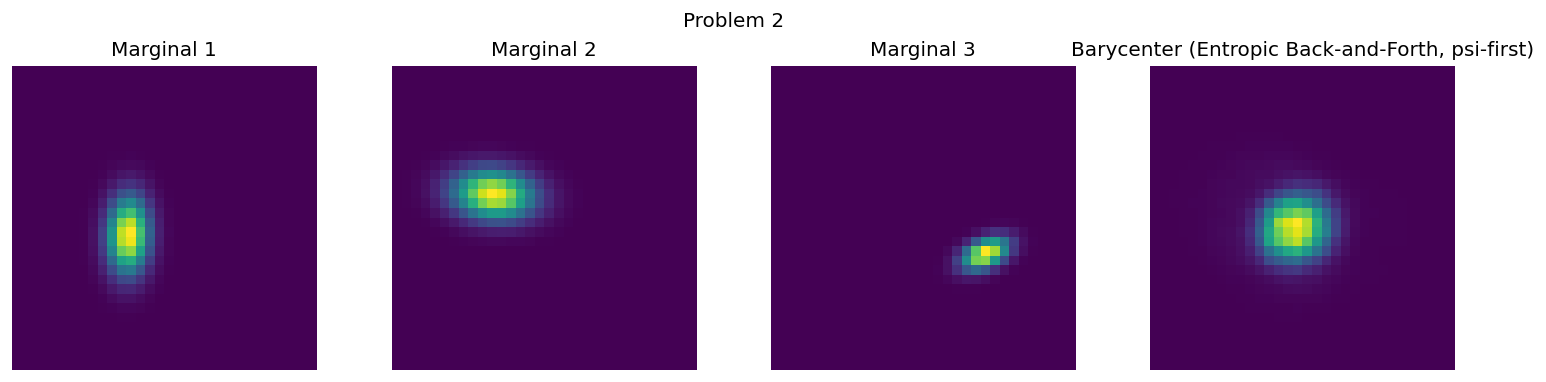

In [13]:
num_measures = len(measures)
fig, axes_arr = plt.subplots(1, num_measures + 1, figsize=(3.2 * (num_measures + 1), 3.2))
if num_measures + 1 == 1:
    axes_arr = [axes_arr]

for j, measure in enumerate(measures, start=1):
    plot_measure(axes_arr[j - 1], measure, f"Marginal {j}")

_plot_density(axes_arr[num_measures], nu_reg, grid_axes, "Barycenter (Entropic Back-and-Forth, psi-first)")

fig.suptitle("Problem 2")
plt.tight_layout()
plt.show()

In [14]:
# Back-and-forth barycenter (library solver)
mu_bf, diag_bf = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=lambdas,
    measures_weights=stacked,
    coordinates=grid_axes,
    outer_maxiter=50,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=1e-3,
    # pushforward_fn=cic_pushforward_nd,
    return_monge_maps=True,
)
mu_bf = mu_bf / jnp.maximum(mu_bf.sum(), 1e-12)


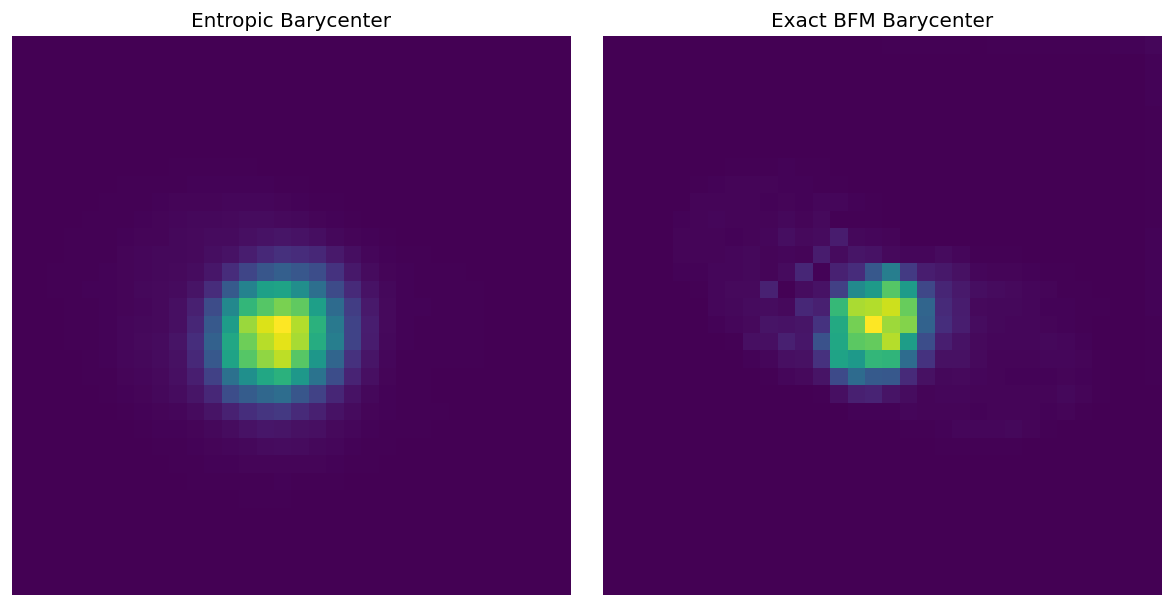

In [15]:
# 2D barycenter comparison (side-by-side)
fig_bary, axes_bary = plt.subplots(nrows=1, ncols=2, figsize=(10.0, 5.0))

_plot_density(axes_bary[0], nu_reg, grid_axes, "Entropic Barycenter")
_plot_density(axes_bary[1], mu_bf, grid_axes, "Exact BFM Barycenter")

plt.tight_layout()
plt.show()


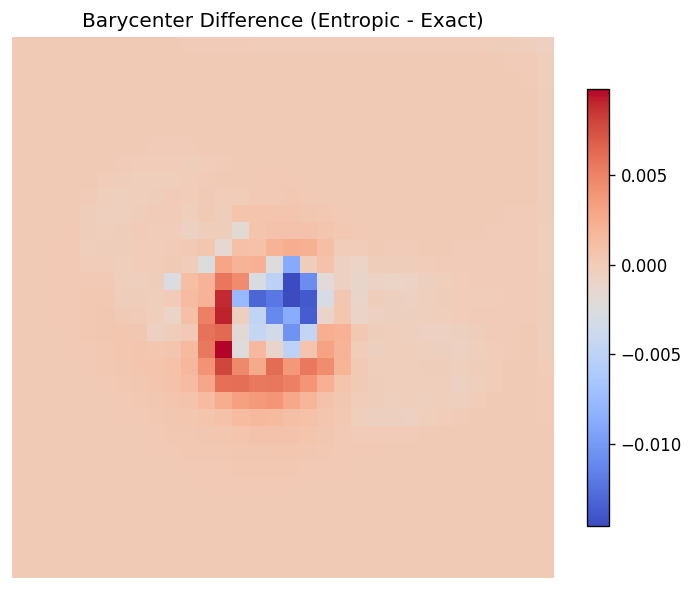

In [16]:
# 2D barycenter difference (entropic - exact)
fig_diff, ax_diff = plt.subplots(nrows=1, ncols=1, figsize=(6.0, 5.0))

diff = np.asarray(nu_reg) - np.asarray(mu_bf)
extent = (
    float(grid_axes[0][0]), float(grid_axes[0][-1]),
    float(grid_axes[1][0]), float(grid_axes[1][-1]),
)
img = ax_diff.imshow(diff.T, extent=extent, origin='lower', cmap='coolwarm')
ax_diff.set_title("Barycenter Difference (Entropic - Exact)")
ax_diff.set_axis_off()
fig_diff.colorbar(img, ax=ax_diff, shrink=0.8)

plt.tight_layout()
plt.show()


In [17]:
# Marginal residuals table (Problem 2)
res_entropic = _marginal_residuals(nu_reg, stacked, grid_axes, phi_stack=phi_reg)
res_bf = _marginal_residuals(mu_bf, stacked, grid_axes, monge_maps=diag_bf.get("monge_maps"))
_print_residual_table("Problem 2 marginal residuals (L1)", {
    "Entropic (debug)": res_entropic,
    "Back-and-forth": res_bf,
})


Problem 2 marginal residuals (L1)
method           | m0        | m1        | m2       
-----------------+-----------+-----------+----------
Entropic (debug) | 2.247e-01 | 2.777e-01 | 2.926e-01
Back-and-forth   | 4.662e-01 | 4.849e-01 | 4.536e-01


---

# TOY GENERATOR (2D) COMPARISON


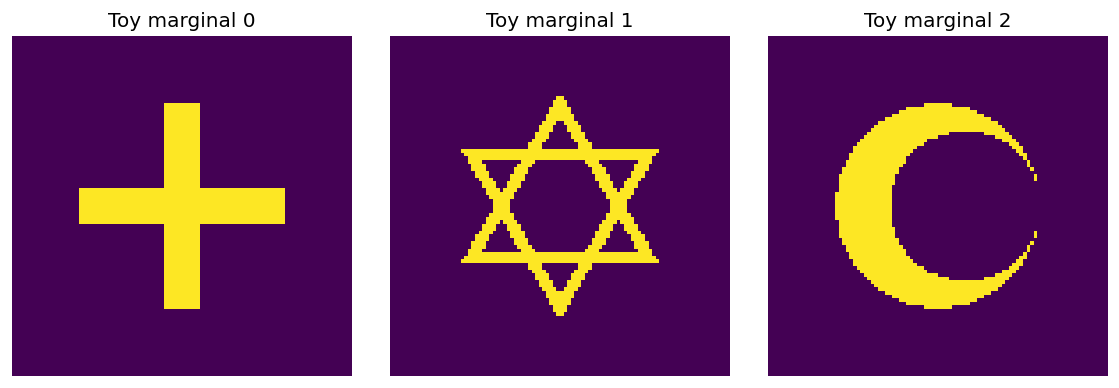

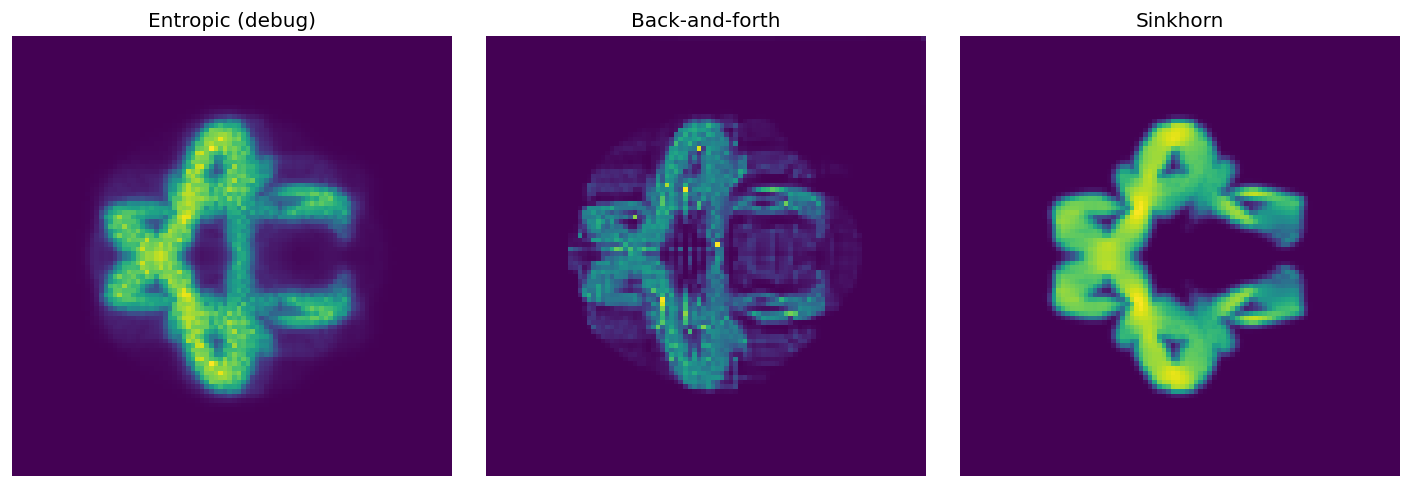

In [21]:
from uot.problems.generators.toy_barycenter_generator import ToyBarycenterGenerator, FixedListSelector
from uot.solvers.back_and_forth.barycenter import backnforth_barycenter_sqeuclidean_nd_optimized
from uot.solvers.sinkhorn.barycenter import barycenter_sinkhorn

# Build a 2D toy barycenter problem with 3 marginals
selector = FixedListSelector(("Plus", "Star", "Crescent"))
toy_gen = ToyBarycenterGenerator(
    selector=selector,
    n_points=96,
    cost_fn=cost_euclid_squared,
    num_datasets=1,
    measure_mode="grid",
    use_jax=False,
    cell_discretization="cell-centered",
)

toy_problem = next(toy_gen.generate(num_marginals=3))
toy_measures = toy_problem.get_marginals()
toy_axes = toy_measures[0].axes
toy_stacked = _stack_grid_measures(toy_measures)
toy_lambdas = jnp.asarray(toy_problem.lambdas())

# Entropic barycenter (debug solver)
start_t = time.perf_counter()
nu_toy, psi_toy, phi_toy, diag_toy = entropic_barycenter_sobolev_gradient_ascent_dual_scan(
    mu_list=[toy_stacked[i] for i in range(toy_stacked.shape[0])],
    lambda_list=toy_lambdas,
    coordinates=toy_axes,
    gamma=1e-4,
    num_outer_iters=1_000,
    outer_tol=5e-4,
    pushforward_fn=cic_pushforward_nd,
)
nu_toy = nu_toy / jnp.maximum(nu_toy.sum(), 1e-12)
runtime_toy_entropic = time.perf_counter() - start_t

# Back-and-forth barycenter (library solver)
start_t = time.perf_counter()
mu_bf_toy, diag_bf_toy = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=toy_lambdas,
    measures_weights=toy_stacked,
    coordinates=toy_axes,
    outer_maxiter=80,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=1e-3,
    # pushforward_fn=cic_pushforward_nd,
    return_monge_maps=True,
)
mu_bf_toy = mu_bf_toy / jnp.maximum(mu_bf_toy.sum(), 1e-12)
runtime_toy_bf = time.perf_counter() - start_t

# Sinkhorn barycenter on shared support
start_t = time.perf_counter()
support, meas_array, cost_matrix, lambdas = toy_problem.shared_support_inputs(
    include_zeros=True,
)
b_sinkhorn, info_sinkhorn = barycenter_sinkhorn(
    measures=jnp.asarray(meas_array),
    cost=jnp.asarray(cost_matrix),
    lambdas=jnp.asarray(lambdas),
    reg=1e-4,
    tol=1e-4,
    maxiter=800,
    return_diagnostics=True,
)

# reshape sinkhorn barycenter to grid for plotting
shape = tuple(len(ax) for ax in toy_axes)
b_sinkhorn_grid = np.asarray(b_sinkhorn).reshape(shape)
runtime_toy_sinkhorn = time.perf_counter() - start_t

# Plot marginals
fig_marg, axes_marg = plt.subplots(1, len(toy_measures), figsize=(3.2 * len(toy_measures), 3.2))
if len(toy_measures) == 1:
    axes_marg = [axes_marg]
for i, m in enumerate(toy_measures):
    plot_measure(axes_marg[i], m, f"Toy marginal {i}")
plt.tight_layout()
plt.show()

# Plot barycenters side-by-side (2D)
fig_bary, axes_bary = plt.subplots(1, 3, figsize=(12.0, 4.0))
_plot_density(axes_bary[0], nu_toy, toy_axes, "Entropic (debug)")
_plot_density(axes_bary[1], mu_bf_toy, toy_axes, "Back-and-forth")
_plot_density(axes_bary[2], b_sinkhorn_grid, toy_axes, "Sinkhorn")
plt.tight_layout()
plt.show()


In [22]:
# Marginal residuals table (Toy generator)
res_toy_entropic = _marginal_residuals(nu_toy, toy_stacked, toy_axes, phi_stack=phi_toy)
res_toy_bf = _marginal_residuals(mu_bf_toy, toy_stacked, toy_axes, monge_maps=diag_bf_toy.get("monge_maps"))
res_toy_sinkhorn = _sinkhorn_barycentric_residuals(
    b_sinkhorn, toy_stacked, support, cost_matrix, reg=5e-4, diagnostics=info_sinkhorn
)
_print_residual_table("Toy marginal residuals (L1)", {
    "Entropic (debug)": res_toy_entropic,
    "Back-and-forth": res_toy_bf,
    "Sinkhorn": res_toy_sinkhorn,
})


Toy marginal residuals (L1)
method           | m0        | m1        | m2       
-----------------+-----------+-----------+----------
Entropic (debug) | 2.974e-01 | 3.657e-01 | 2.586e-01
Back-and-forth   | 3.597e-01 | 1.141e+00 | 3.265e-01
Sinkhorn         | 1.250e+00 | 1.250e+00 | 1.250e+00


In [23]:
# Runtime stats (Toy generator)
_print_runtime_table("Toy runtimes (seconds)", {
    "Entropic (debug)": float(runtime_toy_entropic),
    "Back-and-forth": float(runtime_toy_bf),
    "Sinkhorn": float(runtime_toy_sinkhorn),
})


Toy runtimes (seconds)
method           | seconds
-----------------+--------
Entropic (debug) | 1.313  
Back-and-forth   | 9.128  
Sinkhorn         | 163.470
